# 07 — AI Governance, Ethics and ESG Framework (Day 3D)

## 1. Governance objective

Govern the multimodal AI system already built for the TALA claim-experience
divergence and creator-strategy analysis: public-data collection, text/
image/video processing, claim-evidence fusion, local ChromaDB retrieval,
Gemini-generated answers, citation validation, and creator-strategy
analysis. This notebook builds and inspects the risk register, control
matrix, claim decision policy, RACI, data lifecycle policy, ESG assurance
matrix, regulatory map, GenAI vendor controls, KPI/KRI, incident matrix,
implementation roadmap, and deployment gates.

No new data collection, no external API calls, no change to any existing
analytical result (fusion labels, creator classifications, RAG outputs).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import subprocess
import pandas as pd
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_columns", 30)

TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
from IPython.display import Image
print("Project root:", PROJECT_ROOT)

Project root: D:\MAS Assignment\tala-multimodal-ai


## 2. Intended and prohibited use

This is an **internal decision-support prototype**. It must never be
described or used as an autonomous legal/regulatory decision-maker, proof
that a sustainability claim is true or false, a substitute for
sustainability assurance or product-quality investigation, a customer-facing
claims engine, a creator-risk scoring system, or a system that establishes
misconduct/greenwashing by itself. Four layers stay distinct: evidence
retrieval -> automated classification -> human judgement -> approved
external communication.

## 3. Current safeguards

Already-implemented safeguards confirmed by code inspection: provenance
fields (`src/validation.py`), evidence-strength gates, citation-ID
validation (`src/rag/citation_validator.py`), modality-routing gates,
protected-characteristic exclusion (`src/image_features.py`), face-embedding
exclusion, `.gitignore` secret exclusion, and a 586-test automated suite.

In [2]:
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_governance_framework.py")], check=True)

CompletedProcess(args=['D:\\MAS Assignment\\tala-multimodal-ai\\.venv\\Scripts\\python.exe', 'D:\\MAS Assignment\\tala-multimodal-ai\\scripts\\build_governance_framework.py'], returncode=0)

## 4. Risk methodology

5x5 (likelihood x impact) matrix; scores are structured management
judgements, not empirical probabilities. Levels: 1-4 Low, 5-9 Medium,
10-14 High, 15-25 Critical.

In [3]:
risks = pd.read_csv(TABLES / "ai_governance_risk_register.csv")
print(f"{len(risks)} risks registered")
risks["inherent_risk_level"].value_counts()

26 risks registered


inherent_risk_level
Medium      15
High        10
Critical     1
Name: count, dtype: int64

## 5. Risk register

In [4]:
risks[["risk_id", "risk_domain", "likelihood_1_5", "impact_1_5", "inherent_risk_score",
       "inherent_risk_level", "control_status", "risk_owner"]].sort_values("inherent_risk_score", ascending=False).head(12)

,risk_id,risk_domain,likelihood_1_5,impact_1_5,inherent_risk_score,inherent_risk_level,control_status,risk_owner
8,R09,Defamation and reputational harm,3,5,15,Critical,Proposed,Legal counsel
5,R06,Sampling and representation bias,4,3,12,High,Implemented,AI product owner
9,R10,Greenwashing false positive,3,4,12,High,Proposed,Sustainability/ESG lead
4,R05,Evidence staleness,4,3,12,High,Proposed,AI product owner
6,R07,Creator misrepresentation,3,4,12,High,Partially implemented,Creator-partnership lead
24,R25,Unsupported external communication,3,4,12,High,Proposed,Marketing/brand lead
20,R21,API data exposure,3,4,12,High,Partially implemented,Data Protection Officer
25,R26,Overreliance by management,3,4,12,High,Proposed,Executive sponsor
11,R12,Self-reported evidence treated as independent,3,4,12,High,Implemented,Model-risk/analytics lead
10,R11,Greenwashing false negative,3,4,12,High,Partially implemented,Sustainability/ESG lead


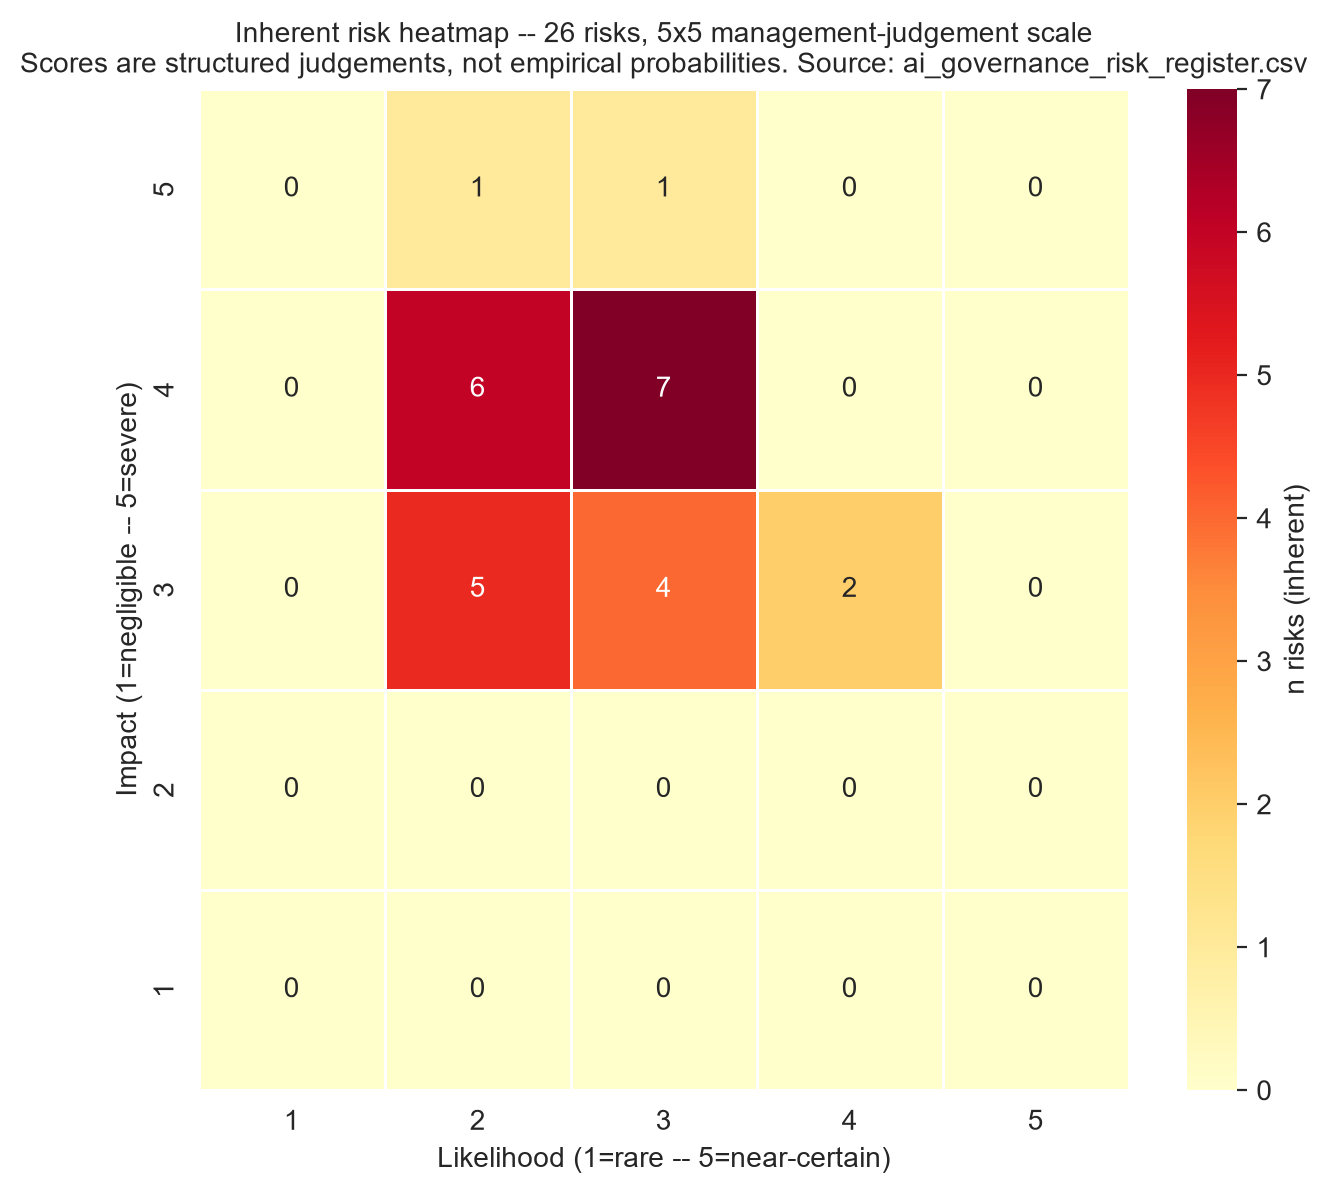

In [5]:
Image(filename=str(FIGURES / "ai_risk_heatmap.png"))

## 6. Control framework

Every High/Critical risk has at least one preventive AND one detective
control (enforced by `scripts/validate_governance_outputs.py` and
`tests/test_governance_framework.py`).

52 controls
control_status
Implemented              37
Proposed                 12
Partially implemented     3
Name: count, dtype: int64
control_type
Preventive    30
Detective     19
Corrective     3
Name: count, dtype: int64


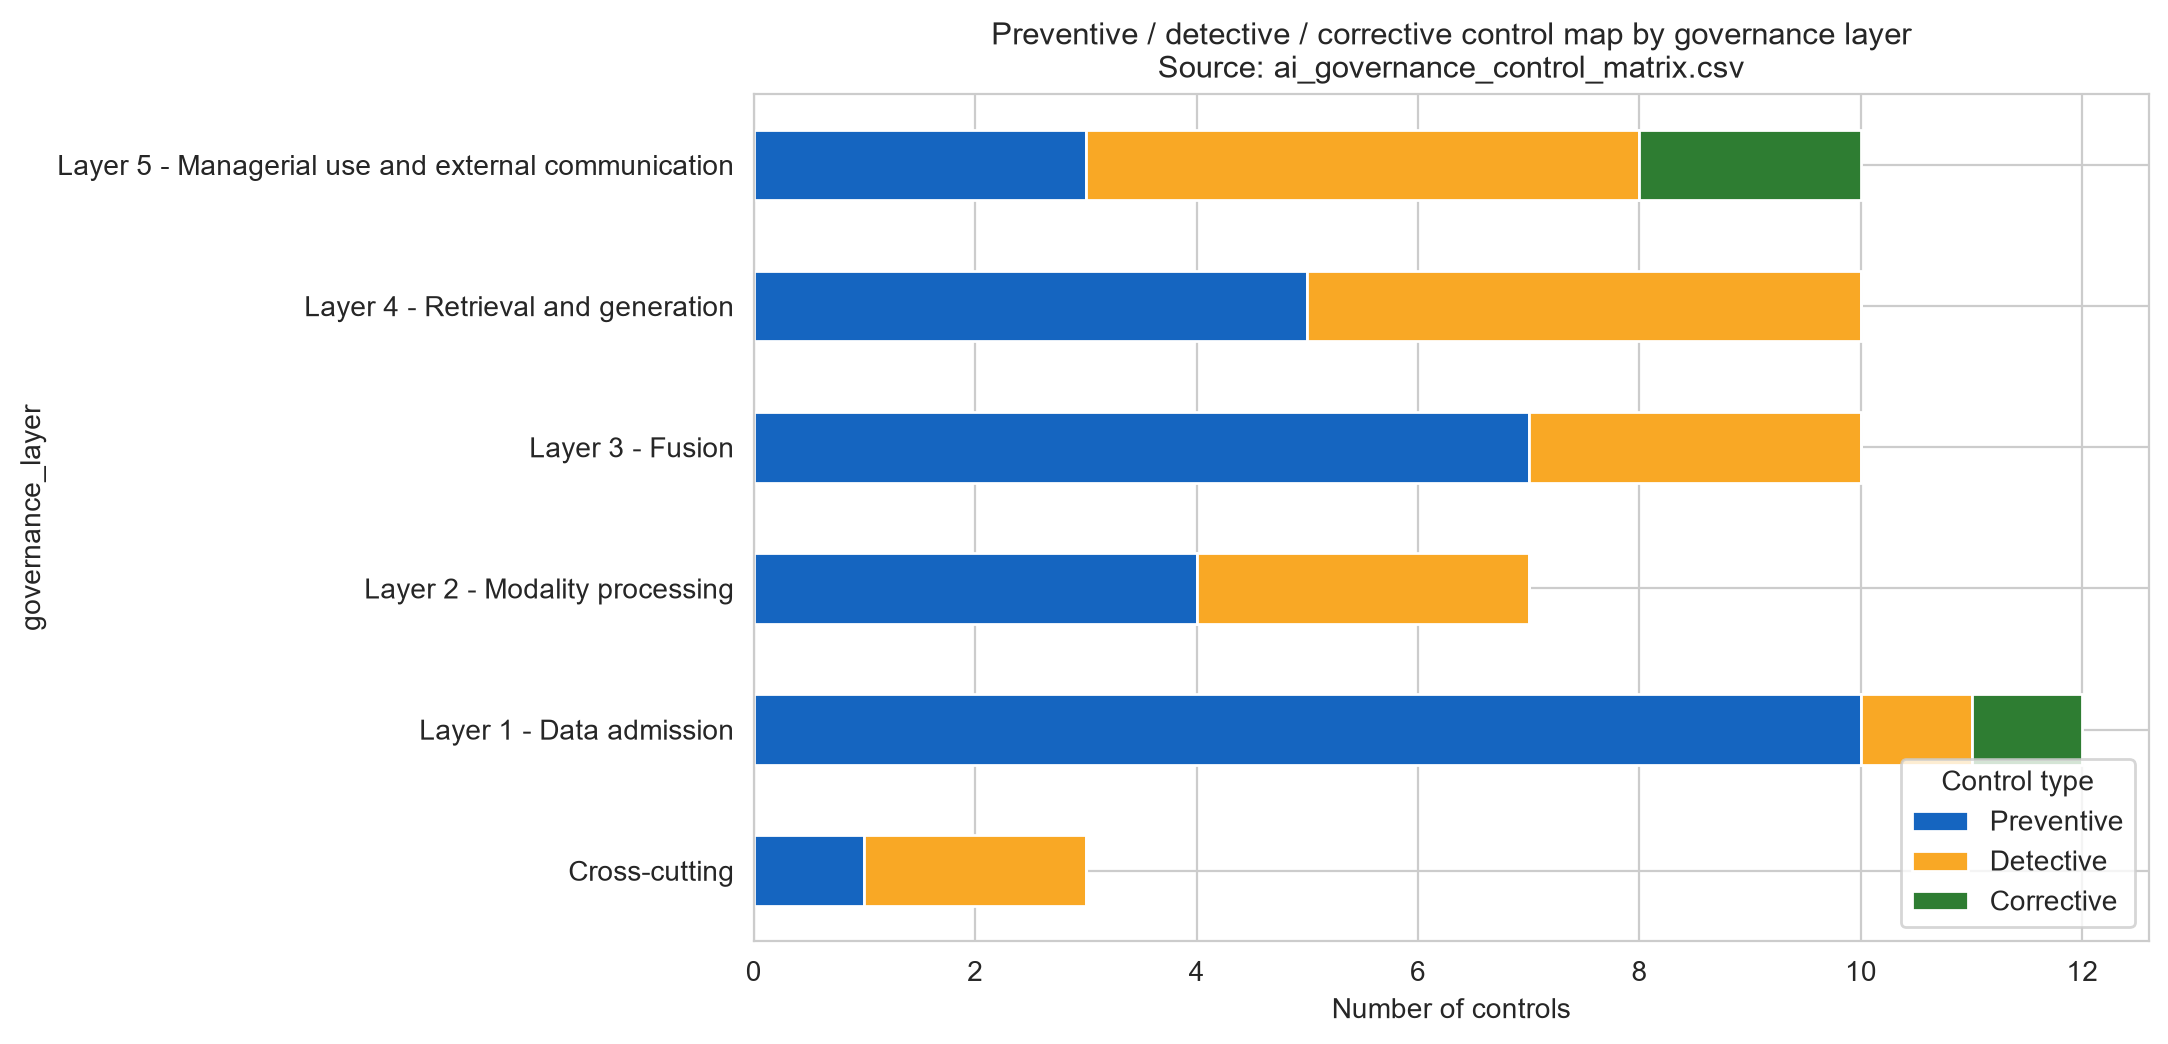

In [6]:
controls = pd.read_csv(TABLES / "ai_governance_control_matrix.csv")
print(f"{len(controls)} controls")
print(controls["control_status"].value_counts())
print(controls["control_type"].value_counts())
Image(filename=str(FIGURES / "prevent_detect_correct_control_map.png"))

## 7. Claim decision policy

Aligned does not mean independently proven; mixed requires presenting both
supporting and challenging evidence; insufficient evidence must never be
described as false.

In [7]:
policy = pd.read_csv(TABLES / "claim_decision_policy.csv")
policy[["decision_label", "meaning", "required_reviewer", "escalation_requirement"]]

,decision_label,meaning,required_reviewer,escalation_requirement
0,aligned,"The automated evidence-gated fusion found supporting evidence (including, for some claims, indep...",Marketing/brand lead; Sustainability/ESG lead if the claim is in a labour/ESG category with inde...,None if independent_evidence_count>0 and not sensitive_to_weights; escalate to Sustainability/ES...
1,partially_aligned,"No claim record currently holds this label (0/37 in the current corpus), but the label remains d...",Sustainability/ESG lead; Legal counsel.,Always escalate before any external use.
2,mixed,Both supporting and challenging evidence exist for this claim record in the verified corpus (5/3...,Legal counsel; Sustainability/ESG lead for labour/ESG-category mixed claims.,Always escalate to the human evidence reviewer and Legal counsel before any external framing; ne...
3,divergent,"No claim record currently holds this label (0/37 in the current corpus), but the label remains d...",Legal counsel; Sustainability/ESG lead; Executive sponsor.,"Mandatory, immediate escalation to Legal counsel and the AI product owner; do not communicate ex..."
4,insufficient_evidence,No qualifying independent/customer/press/reference evidence was found in the verified corpus for...,Sustainability/ESG lead for labour/ESG-category claims; AI product owner otherwise.,"Escalate to Sustainability/ESG lead if the claim is in the labour category (14/37 claims, 0 with..."


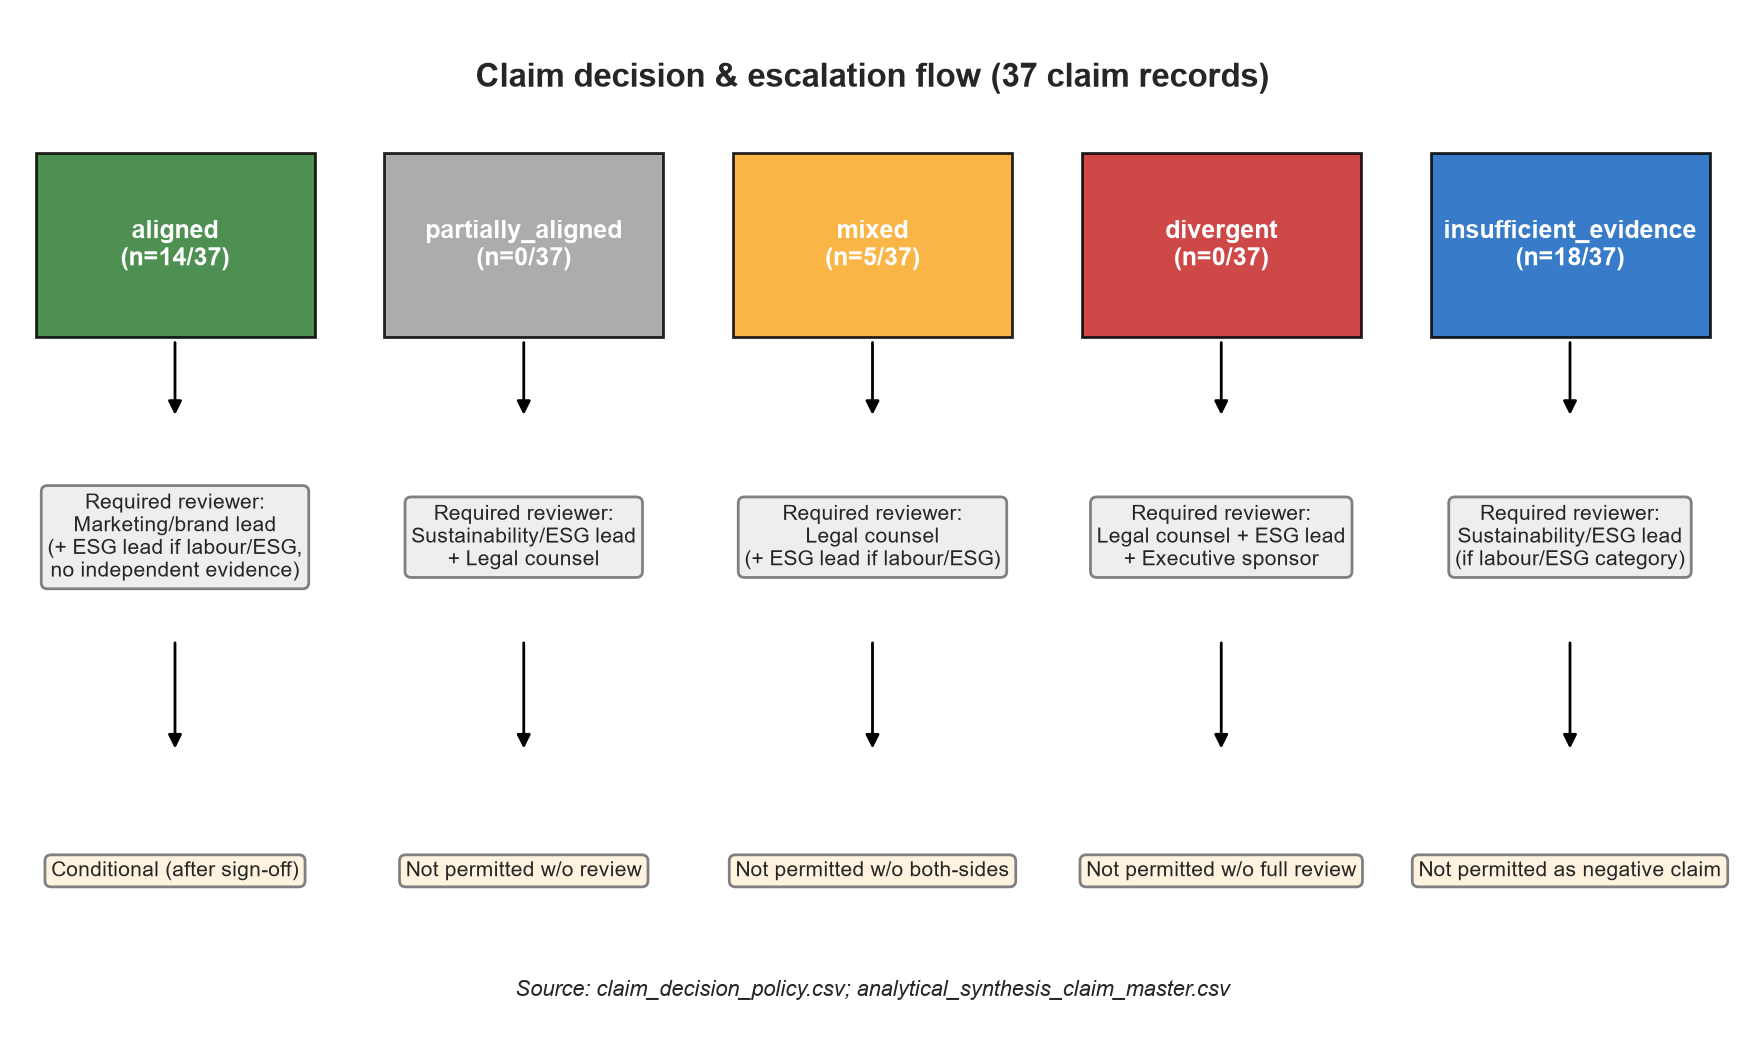

In [8]:
Image(filename=str(FIGURES / "claim_decision_escalation_flow.png"))

## 8. Human accountability

Every governance activity has exactly one Accountable ('A') role.

In [9]:
raci = pd.read_csv(TABLES / "ai_governance_raci.csv")
role_cols = [c for c in raci.columns if c not in ("activity_id", "activity")]
assert ((raci[role_cols] == "A").sum(axis=1) == 1).all()
raci[["activity_id", "activity"]]

,activity_id,activity
0,A01,Source approval
1,A02,Rights-basis approval
2,A03,Data minimisation
3,A04,Evidence refresh
4,A05,Model change
5,A06,Prompt change
6,A07,Claim review
7,A08,Mixed/divergent escalation
8,A09,Sustainability-claim approval
9,A10,Creator-related publication


## 9. Privacy and data lifecycle

In [10]:
lifecycle = pd.read_csv(TABLES / "ai_data_lifecycle_policy.csv")
lifecycle[["lifecycle_stage", "personal_data_risk", "existing_or_proposed_status"]]

,lifecycle_stage,personal_data_risk,existing_or_proposed_status
0,Discovery,Low -- no personal data collected yet,Implemented
1,Collection,Medium -- review/creator text may incidentally reference names in free text,Implemented
2,Admission,Low -- validation does not add new personal fields,Implemented
3,Processing,"Low -- no face embeddings, no protected-characteristic fields (tested)",Implemented
4,Feature extraction,"Low -- embeddings are of public content/images, not of identifiable individuals",Implemented
5,Storage,Medium -- ChromaDB persists evidence text that may incidentally reference third-party names with...,Implemented
6,Retrieval,Low -- retrieval does not expand personal-data surface beyond what is stored,Implemented
7,Generation,Medium -- text sent to a third-party API is subject to Google's data-use terms (tier not confirm...,Implemented (data sent); vendor-tier confirmation proposed
8,Audit logging,Low,Partially implemented
9,Refresh,Same as Collection,Proposed


## 10. Creator/customer ethics

Creator evidence: 60/61 verified records YouTube, 1 TikTok, 0 Instagram --
a targeted recovery sample, never presented as representative.

In [11]:
coverage = pd.read_csv(TABLES / "creator_strategy_evidence_coverage.csv")
coverage[["brand", "verified_creator_records", "platforms_represented_creator"]]

,brand,verified_creator_records,platforms_represented_creator
0,TALA,24,youtube
1,Adanola,16,tiktok;youtube
2,Girlfriend Collective,13,youtube
3,Oner Active,8,youtube


## 11. ESG assurance

Labour is TALA's largest claim category (14/37) and has zero independent
evidence in the current corpus -- the corpus's largest ESG gap.

In [12]:
esg = pd.read_csv(TABLES / "esg_claim_assurance_matrix.csv")
esg[["claim_category", "current_tala_evidence_status", "current_evidence_gap"]]

,claim_category,current_tala_evidence_status,current_evidence_gap
0,Materials,7 materials claims in corpus; some with independent evidence (see analytical_synthesis_claim_mas...,Self-reported material claims outnumber independently corroborated ones
1,Certifications,No certification-registry cross-check currently performed,Certification claims are not independently registry-verified in this corpus
2,Supplier disclosures,"Tier-3 supplier/material-innovation theme: 4 claim variants, all currently mixed","This is the corpus's most concentrated ESG tension -- one recurring claim, evidenced from 4 near..."
3,Labour,14/37 claims are labour-category; 0 have independent evidence in the current corpus (evidence_ga...,This is the single largest ESG evidence gap in the corpus -- TALA's largest claim category is it...
4,Emissions,1 emissions-category claim in corpus (see evidence_gap_by_category.csv),Emissions evidence is essentially absent from the current corpus
5,Circularity,1 circularity-category claim in corpus,Thin single-claim category
6,Packaging,"1 packaging-category claim, zero usable evidence beyond the official claim (evidence_gap_by_cate...",No corroborating or challenging evidence found at all for packaging
7,Garment care and durability,Customer/press durability evidence exists in the broader customer_experience_corpus (95 records)...,Durability evidence exists at the corpus level but is not fully claim-linked for every relevant ...
8,Returns and product quality,customer_experience_corpus.csv (95 records) provides general quality signal not yet all claim-li...,General product-quality sentiment exists but is not exhaustively linked to specific official claims


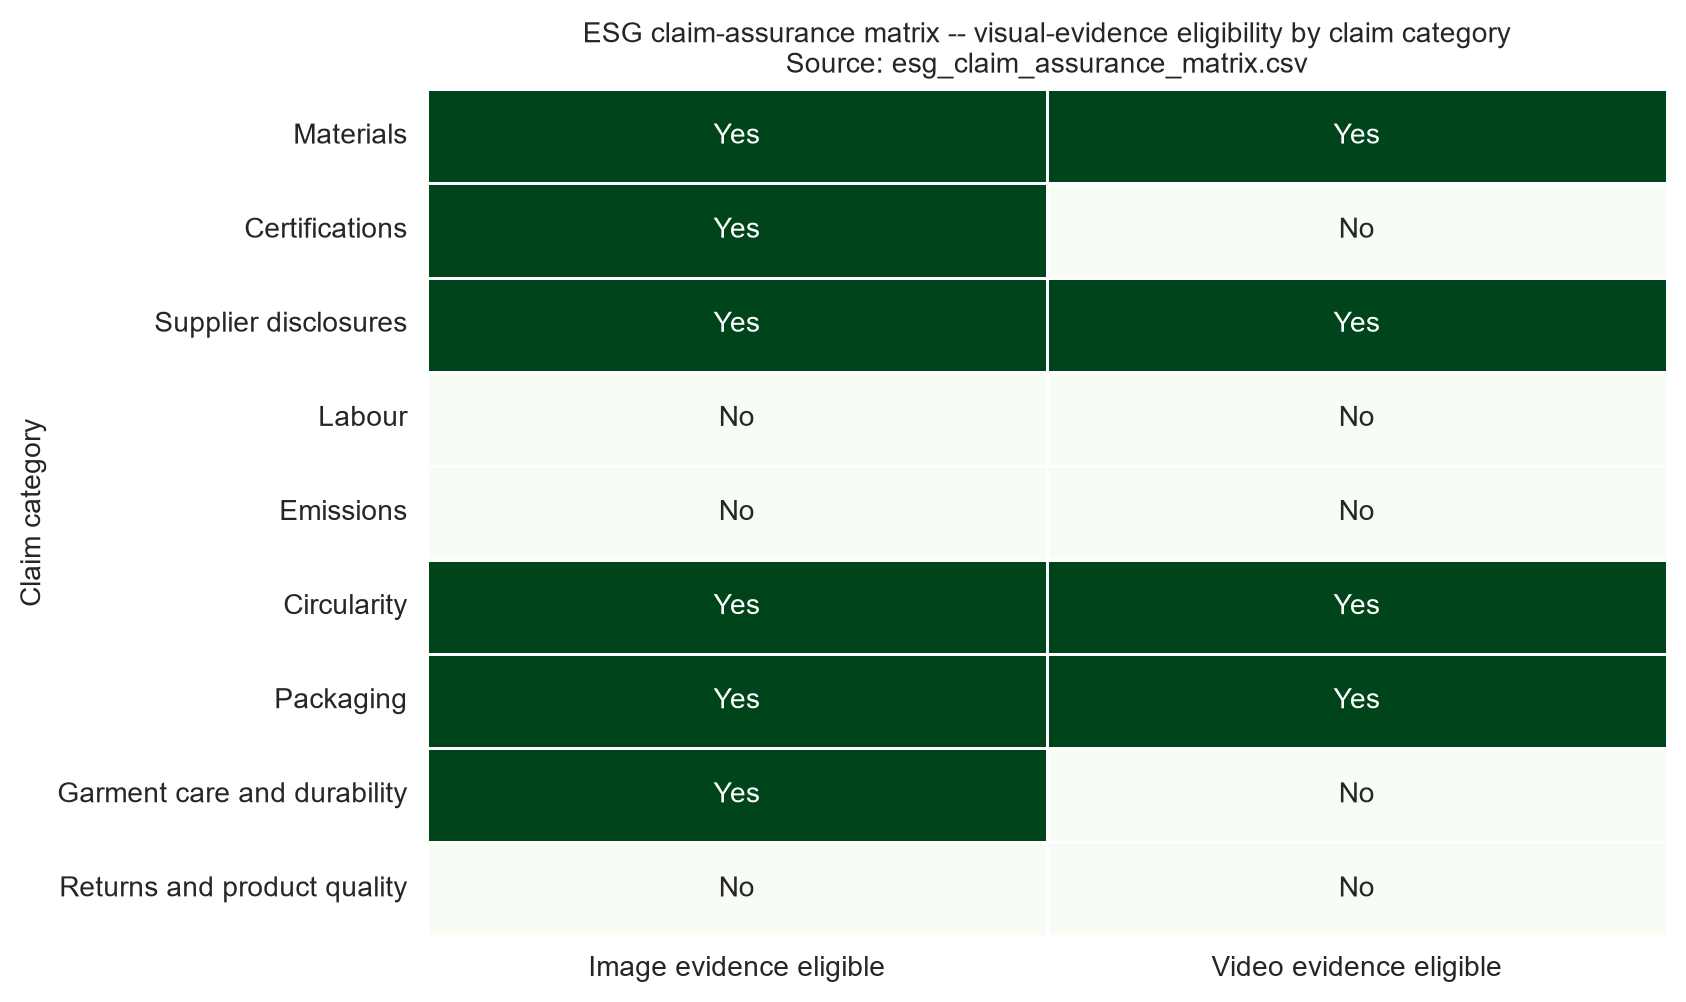

In [13]:
Image(filename=str(FIGURES / "esg_claim_assurance_matrix.png"))

## 12. Regulatory map

Verified 22 September 2026. Voluntary standards (NIST AI RMF, ISO/IEC 42001,
OECD AI Principles) are never labelled mandatory. No definitive EU AI Act
classification is made -- potential applicability only.

In [14]:
reg = pd.read_csv(TABLES / "regulatory_standards_map.csv")
reg[["requirement_id", "authority", "instrument", "mandatory_status", "legal_review_required"]]

,requirement_id,authority,instrument,mandatory_status,legal_review_required
0,REG01,UK Information Commissioner's Office (ICO),Guidance on AI and data protection,"Mandatory (regulator guidance interpreting UK GDPR/DPA 2018, which are themselves mandatory)",True
1,REG02,UK Competition and Markets Authority (CMA),Green Claims Code,"Mandatory (the Code explains existing obligations under UK consumer protection law, which is its...",True
2,REG03,UK Advertising Standards Authority / Committee of Advertising Practice (ASA/CAP),"Environmental claims (CAP Code, non-broadcast, section on environmental claims)",Mandatory for UK advertising (CAP Code is the advertising self-regulatory code backed by law for...,True
3,REG04,European Union (European Parliament and Council),GDPR -- Regulation (EU) 2016/679,Mandatory (for processing EU residents' personal data),True
4,REG05,European Union (European Parliament and Council),EU AI Act -- Regulation (EU) 2024/1689,"Mandatory (regulation), with phased applicability by provision",True
5,REG06,US Federal Trade Commission (FTC),Guides Concerning the Use of Endorsements and Testimonials in Advertising (16 CFR Part 255),"Mandatory for US-directed advertising/endorsements (the Guides interpret the FTC Act, which is m...",True
6,REG07,US National Institute of Standards and Technology (NIST),AI Risk Management Framework (AI RMF 1.0) and Generative AI Profile (NIST-AI-600-1),Voluntary,False
7,REG08,International Organization for Standardization / IEC,ISO/IEC 42001:2023 -- AI management systems,Voluntary,False
8,REG09,Organisation for Economic Co-operation and Development (OECD),OECD AI Principles,Voluntary,False
9,REG10,Google (Gemini API),Gemini API Additional Terms of Service and Data logging/sharing policy,Mandatory (as a contractual condition of using the Gemini API),True


## 13. GenAI vendor controls

There is no fallback model. On any Gemini failure the system stops
generation, shows a clear error, and prevents unsupported output.

In [15]:
genai = pd.read_csv(TABLES / "genai_vendor_control_matrix.csv")
genai[["control_area", "status"]]

,control_area,status
0,Gemini API authentication,Implemented
1,Data sent to Gemini,Implemented
2,Public versus personal information,Partially implemented
3,Context minimisation,Implemented
4,Model-version pinning,Implemented
5,Provider changes,Implemented
6,Rate limits,Not applicable / vendor-managed
7,API failure,Implemented
8,Logging,Partially implemented
9,Data-use terms,Gap -- proposed to confirm


## 14. Monitoring indicators

Current values are computed from repository outputs where feasible; `TBC`
is used everywhere a value cannot yet be calculated -- never fabricated.

In [16]:
kpi = pd.read_csv(TABLES / "ai_governance_kpi_kri.csv")
kpi[["kpi_kri", "current_value", "target"]]

,kpi_kri,current_value,target
0,Provenance completeness,100.0% (33/33 files passed scripts/validate_data.py provenance checks at last run),99%
1,Evidence-strength completeness,TBC (no single repository output currently aggregates evidence_strength null-rate across all cor...,99%
2,Unresolved source rate,"TBC (would require a live URL-liveness check, which this task does not perform)",<2%
3,Citation-validation failure rate,0.0%,0%
4,Unsupported citation rate,TBC (see rag_citation_validation.csv failure category breakdown for the underlying detail),0%
5,Label-preservation failure rate,TBC (no dedicated production monitoring job runs this check continuously),0%
6,Missing-asset rate,"TBC (would require a live media_path file-existence sweep, not run in this task)",<1%
7,Duplicate evidence rate,0% (src/validation.py assert_no_duplicate_ids() blocks duplicate writes at build time),0%
8,Retrieval recall@k,TBC (see outputs/tables/rag_retrieval_evaluation.csv for the underlying per-query detail),TBC (target to be set after a larger evaluation query set exists)
9,Evidence-staleness rate,TBC (no staleness threshold/scheduler currently implemented; see risk R05),<20%


## 15. Incident management

In [17]:
incidents = pd.read_csv(TABLES / "ai_incident_escalation_matrix.csv")
incidents[["incident_scenario", "severity", "notification_owner", "target_response_time"]]

,incident_scenario,severity,notification_owner,target_response_time
0,Exposed API key (Gemini/YouTube/Apify/etc.),Critical,Information Security lead,<4 hours
1,Personal data accidentally retained (e.g. un-stripped username),High,Data steward,<48 hours
2,Invalid or fabricated citation in a Gemini answer,High,Model-risk/analytics lead,<24 hours
3,Unsupported greenwashing allegation surfaces (internal or external),Critical,Marketing/brand lead,<24 hours
4,Creator misidentification or misattributed partnership type,High,Creator-partnership lead,<48 hours
5,Copyright complaint (image/video asset),High,Legal counsel,<72 hours
6,"Wrong fusion label displayed (code/data defect, not an adjudication disagreement)",High,Model-risk/analytics lead,<24 hours
7,Gemini model behaviour change (Google-side),Medium,AI product owner,<5 business days
8,Retrieval/index corruption (ChromaDB),Medium,Information Security lead,<48 hours
9,Stale certification/ESG evidence discovered,Medium,Sustainability/ESG lead,<10 business days


## 16. Implementation roadmap

phase
Phase 1 - Controlled internal pilot (0-30 days)       8
Phase 2 - Limited business deployment (31-90 days)    8
Phase 3 - Scaled deployment (3-6 months)              7
Phase 0 - Academic prototype (current state)          3
Name: count, dtype: int64


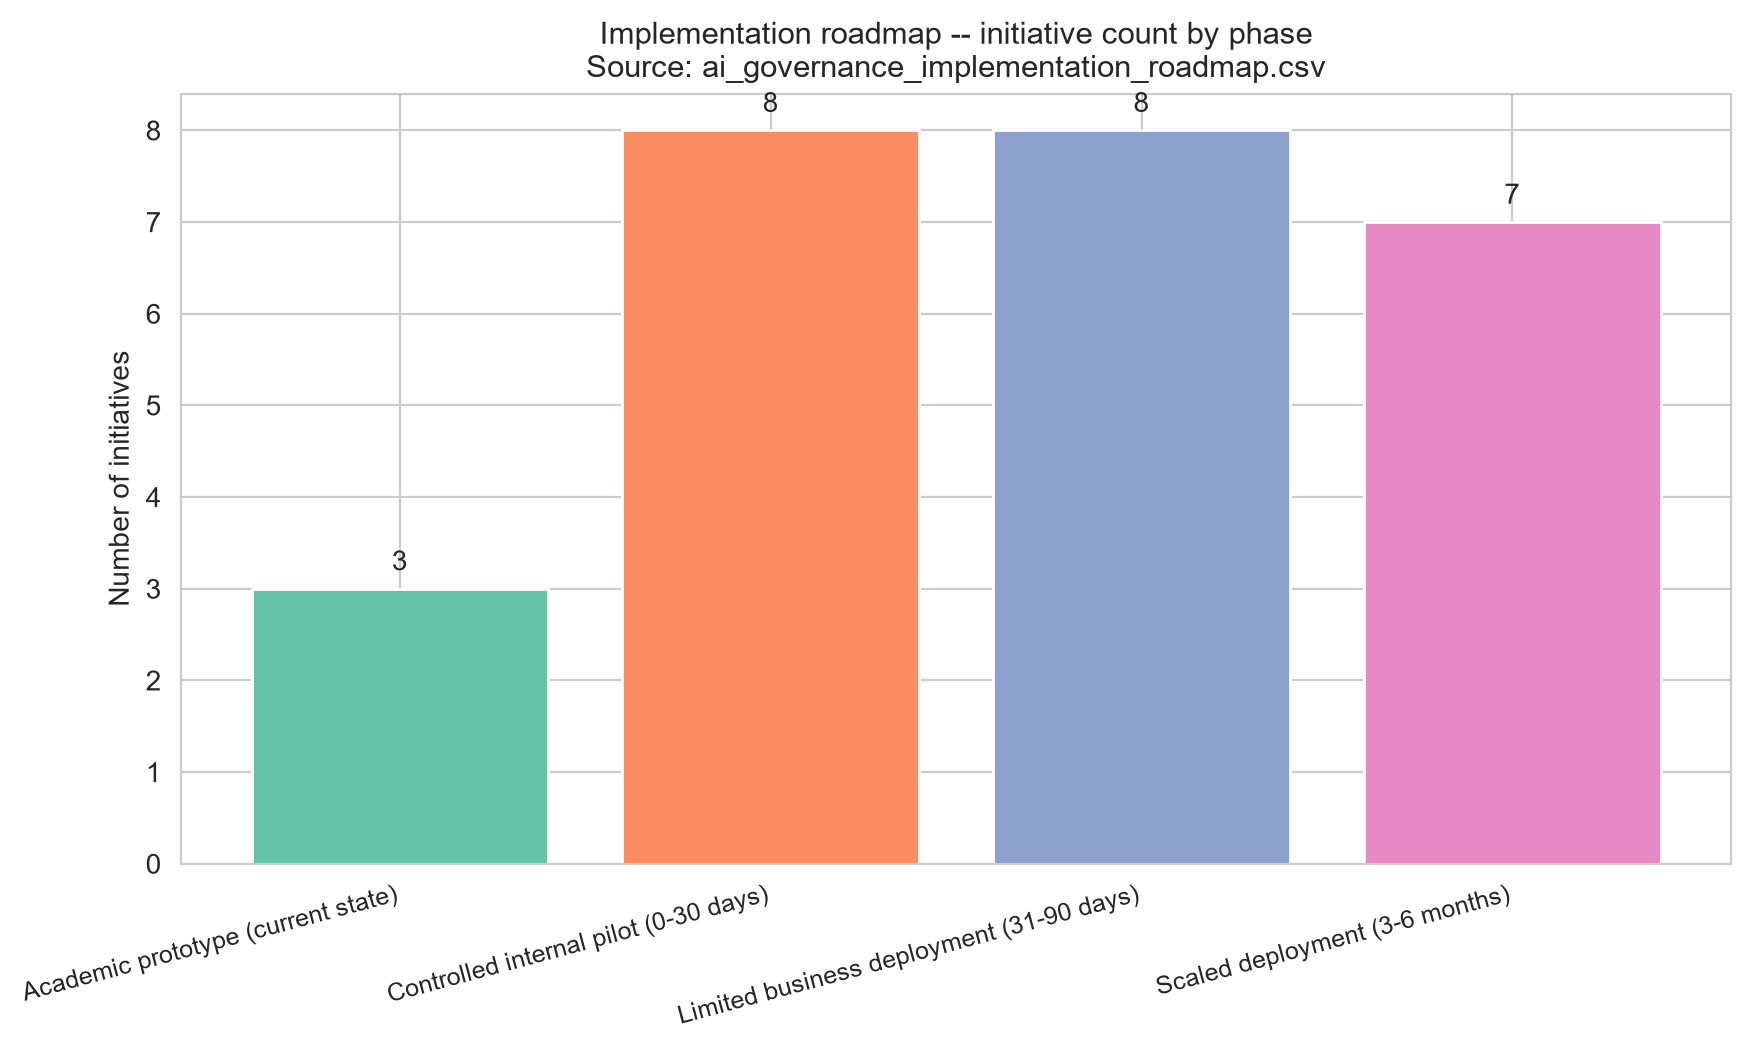

In [18]:
roadmap = pd.read_csv(TABLES / "ai_governance_implementation_roadmap.csv")
print(roadmap["phase"].value_counts())
Image(filename=str(FIGURES / "ai_governance_implementation_roadmap.png"))

In [19]:
subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / "build_governance_figures.py")], check=True)

CompletedProcess(args=['D:\\MAS Assignment\\tala-multimodal-ai\\.venv\\Scripts\\python.exe', 'D:\\MAS Assignment\\tala-multimodal-ai\\scripts\\build_governance_figures.py'], returncode=0)

## 17. Deployment gates

Academic demonstration: GO. Controlled internal pilot: PARTIAL. External/
customer-facing deployment: NO-GO. Evidence-based, not preassigned.

In [20]:
gates = pd.read_csv(TABLES / "ai_governance_go_no_go.csv")
gates.pivot(index="gate", columns="deployment_context", values="status")

deployment_context,academic_demonstration_readiness,controlled_internal_pilot_readiness,external_customer_facing_deployment_readiness
gate,,,
Citation integrity,GO,PARTIAL,NO-GO
Data governance,GO,PARTIAL,NO-GO
ESG assurance,GO,PARTIAL,NO-GO
Evidence quality,GO,PARTIAL,NO-GO
Human oversight,GO,PARTIAL,NO-GO
Incident response,GO,PARTIAL,NO-GO
Media rights,GO,PARTIAL,NO-GO
Model documentation,GO,PARTIAL,NO-GO
Monitoring,GO,PARTIAL,NO-GO


## 18. Final recommendations

1. Present this system as academic-demonstration-ready, pilot-conditional,
   and not ready for external/customer-facing deployment.
2. Prioritise closing the labour-evidence gap (14/37 claims, 0 independent
   evidence) before any ESG-related external communication.
3. Confirm the Gemini API account tier (free vs. paid) before any wider use.
4. Stand up the human-approval and sustainability-review sign-off workflows
   before treating any finding as pilot-ready.
5. Present the single Critical risk (R09 -- defamation/reputational harm)
   and its controls explicitly to any faculty/business audience.

Full narrative: `docs/ai_governance_ethics_esg_framework.md`.